# Module 09 - Transformer Block

Use this notebook after implementing the Module 09 library scaffolds. The goal is to make the transformer block physical: LayerNorm normalizes each token vector, the FFN works independently per position, residuals preserve the stream, and `TransformerLM` turns a stack of blocks into `(B, T, V)` logits.

1. Read the lesson page (`docs/modules/09-transformer-block.md`).
2. Open this notebook with `.venv/bin/python scripts/open_notebook.py 09`.
3. Answer the `Question:` / `Answer:` cells below.
4. When you're ready, ask a coding agent to grade your notebook.

Partial work is fine. Blank `Answer: ""` strings are skipped, not counted wrong. If you'd like a hint instead of a grade, write the request inline in the answer string and the agent will tutor first.

In [1]:
from __future__ import annotations

import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch

import g2c
from g2c.nn import CrossEntropyLoss, SGD, resolve_device
from g2c.transformer import Block, FeedForward, LayerNorm, TransformerLM

_ = torch.manual_seed(0)
repo_root = Path(g2c.__file__).resolve().parents[1]
experiment_device = "auto"
print("MPS available:", torch.backends.mps.is_available())

MPS available: True


## Before the Notebook

Implement `LayerNorm.forward`, `FeedForward.forward`, `Block.forward`, and `TransformerLM.forward` first. The notebook calls those methods directly, so use the tests as the implementation guide before treating these cells as experiments.

In [2]:
"Run from the terminal: .venv/bin/python -m pytest tests/test_transformer.py -x"
"Question: Which transformer test is the next one failing, and what exact contract does it point at?"
"Answer: "

'Answer: '

In [3]:
result = subprocess.run(
    [sys.executable, "-m", "pytest", "tests/test_transformer.py"],
    cwd=repo_root,
    text=True,
    capture_output=True,
)
print(result.stdout)
if result.stderr:
    print(result.stderr)

assert result.returncode == 0, "Module 09 transformer tests are not passing yet."
print("Module 09 transformer tests passed.")

..................................................                       [100%]
50 passed in 0.59s

Module 09 transformer tests passed.


## Exercise 1 - LayerNorm on One Batch

Predict the output statistics before running the check. LayerNorm should normalize across the last dimension only, so each `(batch, position)` slice gets its own mean and variance.

In [4]:
"Question: For an input shaped (2, 3, 8), how many separate means does LayerNorm compute?"
"Answer: "
"Question: Why does LayerNorm use unbiased=False for the variance?"
"Answer: "

'Answer: '

In [5]:
ln = LayerNorm(embedding_dim=8)
x = torch.randn(2, 3, 8) * 3.0 + 7.0
y = ln(x)

print("input shape:", tuple(x.shape))
print("output shape:", tuple(y.shape))
print("per-position means after LN:\n", y.mean(dim=-1))
print("per-position variances after LN:\n", y.var(dim=-1, unbiased=False))

assert y.shape == x.shape
assert torch.allclose(y.mean(dim=-1), torch.zeros(2, 3), atol=1e-5)
assert torch.allclose(y.var(dim=-1, unbiased=False), torch.ones(2, 3), atol=1e-4)

input shape: (2, 3, 8)
output shape: (2, 3, 8)
per-position means after LN:
 tensor([[ 1.1921e-07, -1.4901e-08,  2.9802e-08],
        [-4.4703e-08, -3.2783e-07, -4.4703e-08]], grad_fn=<MeanBackward1>)
per-position variances after LN:
 tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]], grad_fn=<VarBackward0>)


## Exercise 2 - The FFN Is Per-Position

Attention mixes information across positions. The FFN does not. It applies the same two-layer MLP to every position independently.

In [6]:
"Question: If you mutate token position 2, which FFN outputs should change?"
"Answer: "
"Question: Why does the FFN expand to hidden_dim = 4 * embedding_dim before projecting back down?"
"Answer: "

'Answer: '

In [7]:
torch.manual_seed(0)
ffn = FeedForward(embedding_dim=8, hidden_dim=32)
x1 = torch.randn(1, 4, 8)
x2 = x1.clone()
x2[0, 2, :] = torch.randn(8)

y1 = ffn(x1)
y2 = ffn(x2)

for pos in range(4):
    changed = not torch.allclose(y1[0, pos], y2[0, pos], atol=1e-6)
    print(f"position {pos}: changed={changed}")

assert torch.allclose(y1[0, 0], y2[0, 0], atol=1e-6)
assert torch.allclose(y1[0, 1], y2[0, 1], atol=1e-6)
assert not torch.allclose(y1[0, 2], y2[0, 2], atol=1e-4)
assert torch.allclose(y1[0, 3], y2[0, 3], atol=1e-6)

position 0: changed=False
position 1: changed=False
position 2: changed=True
position 3: changed=False


## Exercise 3 - Residual Identity Check

A transformer block should pass the residual stream through unchanged when both sublayers write zero updates. This is the concrete test for the residual structure.

In [8]:
"Question: Why does zeroing the final attention and FFN projections make each sublayer output zero?"
"Answer: "
"Question: What would this cell print if Block.forward forgot the residual additions?"
"Answer: "

'Answer: '

In [9]:
torch.manual_seed(0)
block = Block(embedding_dim=8, num_heads=2, hidden_dim=16, causal=True)
with torch.no_grad():
    block.attn.out_proj.W.zero_()
    block.attn.out_proj.b.zero_()
    block.ffn.fc2.W.zero_()
    block.ffn.fc2.b.zero_()

x = torch.randn(2, 4, 8)
y = block(x)
print("max absolute difference from identity:", (y - x).abs().max().item())
assert torch.allclose(y, x, atol=1e-6)

max absolute difference from identity: 0.0


## Exercise 4 - Pre-Norm vs Post-Norm

The production block is pre-norm: `x = x + sublayer(LN(x))`. This experiment defines a post-norm variant and trains both on the same tiny repeated-token corpus. The default step count is small so the first run is quick; increase it after the plumbing works.

In [10]:
class PostNormBlock(Block):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.ln1(x + self.attn(x))
        x = self.ln2(x + self.ffn(x))
        return x


def make_lm_with_block(
    block_cls,
    *,
    vocab_size: int = 50,
    embedding_dim: int = 64,
    num_layers: int = 6,
    num_heads: int = 4,
    max_seq_len: int = 32,
    hidden_dim: int | None = None,
) -> TransformerLM:
    model = TransformerLM(
        vocab_size=vocab_size,
        embedding_dim=embedding_dim,
        num_layers=num_layers,
        num_heads=num_heads,
        max_seq_len=max_seq_len,
        hidden_dim=hidden_dim,
    )
    model.blocks = [
        block_cls(
            embedding_dim,
            num_heads,
            hidden_dim=model.hidden_dim,
            causal=True,
        )
        for _ in range(num_layers)
    ]
    return model

In [11]:
loss_fn = CrossEntropyLoss()


def lm_loss(logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
    B, T, V = logits.shape
    return loss_fn(logits.reshape(B * T, V), targets.reshape(B * T))


def get_sequence_batch(
    ids: torch.Tensor,
    *,
    batch_size: int,
    context_length: int,
    generator: torch.Generator,
) -> tuple[torch.Tensor, torch.Tensor]:
    starts = torch.randint(0, len(ids) - context_length, (batch_size,), generator=generator)
    x = torch.stack([ids[s : s + context_length] for s in starts])
    y = torch.stack([ids[s + 1 : s + context_length + 1] for s in starts])
    return x, y


def train_tiny_transformer(
    model: TransformerLM,
    ids: torch.Tensor,
    *,
    steps: int = 300,
    lr: float = 1e-3,
    batch_size: int = 32,
    context_length: int = 32,
    log_every: int = 25,
    seed: int = 0,
    device=experiment_device,
) -> list[tuple[int, float]]:
    device = resolve_device(device)
    model.to(device)
    optimizer = SGD(model.parameters(), lr=lr)
    generator = torch.Generator().manual_seed(seed)
    curve: list[tuple[int, float]] = []

    for step in range(steps):
        xb, yb = get_sequence_batch(
            ids,
            batch_size=batch_size,
            context_length=context_length,
            generator=generator,
        )
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = lm_loss(logits, yb)
        loss.backward()
        optimizer.step()

        if step % log_every == 0 or step == steps - 1:
            curve.append((step, float(loss.item())))

    return curve

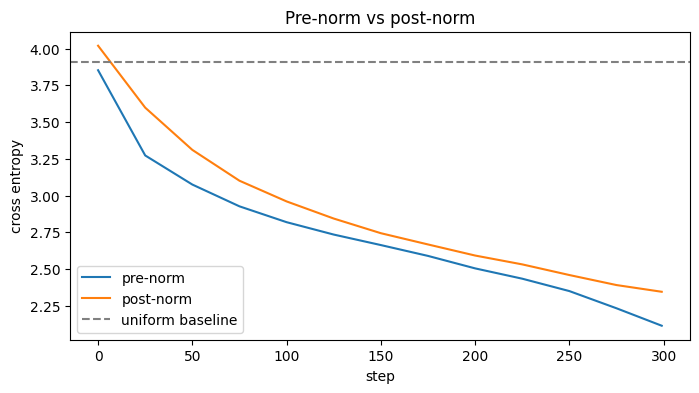

In [12]:
pattern = torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 3, 4, 5, 6, 7, 0], dtype=torch.long)
toy_ids = pattern.repeat(200)

experiment_steps = 300
torch.manual_seed(1)
pre_norm_model = make_lm_with_block(Block)
pre_curve = train_tiny_transformer(pre_norm_model, toy_ids, steps=experiment_steps, lr=1e-3)

torch.manual_seed(1)
post_norm_model = make_lm_with_block(PostNormBlock)
post_curve = train_tiny_transformer(post_norm_model, toy_ids, steps=experiment_steps, lr=1e-3)

plt.figure(figsize=(8, 4))
plt.plot([s for s, _ in pre_curve], [v for _, v in pre_curve], label="pre-norm")
plt.plot([s for s, _ in post_curve], [v for _, v in post_curve], label="post-norm")
plt.axhline(math.log(50), color="gray", linestyle="--", label="uniform baseline")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.title("Pre-norm vs post-norm")
plt.legend()
plt.show()

In [13]:
"Question: Which curve is smoother in your run, and what does that suggest about the residual gradient path?"
"Answer: "
"Question: If post-norm trains fine after adding warmup in Module 10, does that make pre-norm unnecessary? Why or why not?"
"Answer: "

'Answer: '

## Exercise 5 - Strip Residuals or Strip LayerNorm

These variants are intentionally bad. The point is to see that residuals and normalization are not cosmetic additions around attention; they are what make stacked blocks trainable.

In [14]:
class ResidualFreeBlock(Block):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.attn(self.ln1(x))
        x = self.ffn(self.ln2(x))
        return x


class NoNormBlock(Block):
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = x + self.attn(x)
        x = x + self.ffn(x)
        return x


def run_depth_sweep(block_cls, depths: list[int], *, steps: int = 200) -> dict[int, list[tuple[int, float]]]:
    curves: dict[int, list[tuple[int, float]]] = {}
    for depth in depths:
        torch.manual_seed(2)
        model = make_lm_with_block(block_cls, num_layers=depth, embedding_dim=48, num_heads=4, max_seq_len=32)
        curves[depth] = train_tiny_transformer(model, toy_ids, steps=steps, lr=1e-3, batch_size=32)
    return curves

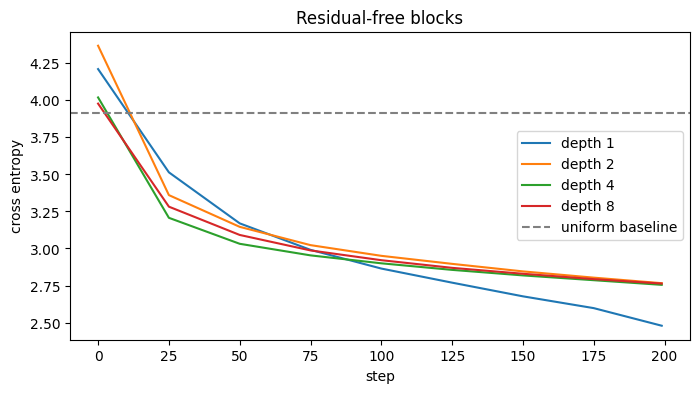

In [15]:
depths = [1, 2, 4, 8]
residual_free_curves = run_depth_sweep(ResidualFreeBlock, depths, steps=200)

plt.figure(figsize=(8, 4))
for depth, curve in residual_free_curves.items():
    plt.plot([s for s, _ in curve], [v for _, v in curve], label=f"depth {depth}")
plt.axhline(math.log(50), color="gray", linestyle="--", label="uniform baseline")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.title("Residual-free blocks")
plt.legend()
plt.show()

In [16]:
"Question: At what depth did the residual-free model stop making meaningful progress?"
"Answer: "
"Question: How does this connect to the residual-stream explanation in the module?"
"Answer: "

'Answer: '

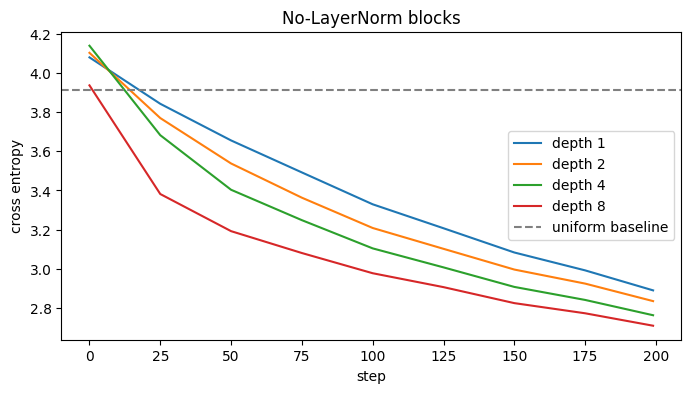

In [17]:
no_norm_curves = run_depth_sweep(NoNormBlock, depths, steps=200)

plt.figure(figsize=(8, 4))
for depth, curve in no_norm_curves.items():
    plt.plot([s for s, _ in curve], [v for _, v in curve], label=f"depth {depth}")
plt.axhline(math.log(50), color="gray", linestyle="--", label="uniform baseline")
plt.xlabel("step")
plt.ylabel("cross entropy")
plt.title("No-LayerNorm blocks")
plt.legend()
plt.show()

In [18]:
"Question: Does removing LayerNorm fail in the same way as removing residuals, or is the curve different?"
"Answer: "
"Question: Which symptom would make you suspect scale instability rather than missing gradient flow?"
"Answer: "

'Answer: '

## Exercise 6 - TransformerLM Shape and Parameter Budget

The full language model returns one vocab-sized logit vector per position. Then parameter counting tells you where the model's capacity lives.

In [19]:
torch.manual_seed(0)
m = TransformerLM(vocab_size=32, embedding_dim=32, num_layers=2, num_heads=4, max_seq_len=16)
ids = torch.randint(0, 32, (3, 10))
logits = m(ids)
print("ids:", tuple(ids.shape))
print("logits:", tuple(logits.shape))
assert logits.shape == (3, 10, 32)

ids: (3, 10)
logits: (3, 10, 32)


In [20]:
def count_params(model) -> int:
    return sum(p.numel() for p in model.parameters())


def analytical_transformer_params(
    *,
    vocab_size: int,
    embedding_dim: int,
    num_layers: int,
    max_seq_len: int,
    hidden_dim: int | None = None,
) -> int:
    D = embedding_dim
    H_ff = 4 * D if hidden_dim is None else hidden_dim
    token_embed = vocab_size * D       # also serves as the unembedding (tied)
    pos_embed = max_seq_len * D
    mha = 4 * (D * D + D)
    ffn = (D * H_ff + H_ff) + (H_ff * D + D)
    lns_per_block = 4 * D
    per_block = mha + ffn + lns_per_block
    final_ln = 2 * D
    head_bias = vocab_size              # only the per-token bias; the matrix is tied
    return token_embed + pos_embed + num_layers * per_block + final_ln + head_bias


configs = [
    dict(vocab_size=100, embedding_dim=32, num_layers=2, num_heads=4, max_seq_len=32),
    dict(vocab_size=100, embedding_dim=64, num_layers=4, num_heads=4, max_seq_len=32),
    dict(vocab_size=500, embedding_dim=64, num_layers=2, num_heads=4, max_seq_len=64),
]

for cfg in configs:
    model = TransformerLM(**cfg)
    actual = count_params(model)
    expected = analytical_transformer_params(
        vocab_size=cfg["vocab_size"],
        embedding_dim=cfg["embedding_dim"],
        num_layers=cfg["num_layers"],
        max_seq_len=cfg["max_seq_len"],
    )
    untied_total = expected + cfg["vocab_size"] * cfg["embedding_dim"]
    saving = untied_total - expected
    print(cfg)
    print(f"  actual={actual:,}  analytical={expected:,}")
    print(f"  tying saved {saving:,} params (= V*D), {saving/untied_total:.1%} of the untied total")
    assert actual == expected


{'vocab_size': 100, 'embedding_dim': 32, 'num_layers': 2, 'num_heads': 4, 'max_seq_len': 32}
  actual=29,796  analytical=29,796
  tying saved 3,200 params (= V*D), 9.7% of the untied total
{'vocab_size': 100, 'embedding_dim': 64, 'num_layers': 4, 'num_heads': 4, 'max_seq_len': 32}
  actual=208,612  analytical=208,612
  tying saved 6,400 params (= V*D), 3.0% of the untied total
{'vocab_size': 500, 'embedding_dim': 64, 'num_layers': 2, 'num_heads': 4, 'max_seq_len': 64}
  actual=136,692  analytical=136,692
  tying saved 32,000 params (= V*D), 19.0% of the untied total


In [21]:
"Question: For which of the three configs above does tying save the largest fraction of total params?"
"Answer: "
"Question: As D grows (holding V fixed), does the relative tying saving grow or shrink? Why?"
"Answer: "


'Answer: '

In [22]:
"Question: In the configs above, when do embeddings dominate and when do blocks dominate?"
"Answer: "
"Question: Why does the FFN usually contain more parameters than attention inside one block?"
"Answer: "

'Answer: '